**Next steps**
1. restart: focus in on Skagit Bay and CLIP data pls
2. load in data as lat lon and reproject later
3. remove clouds
4. remove images that have less than a set threshold % of information
5. mask the land dataset
6. pick a month (either June or July)
7. plot RGB
8. plot NDCI, using the article w/ linear relationship to define vmin and vmax
9. calculate median ncdi over time (month) for each year (give to Gaurav)
10. Use linear relationship to back out chlorophyll concentrations (give to Gaurav)
11. maybe make that plot with whidbey basin and points with the buoys using chorophyll as gradient for different discharge events (try for Skagit)

**For presentation**
1. introduce phenomenon
2. initial visualization video with LiveOcean
3. explain how models are still unpredictable and that we can use actual observations with river concentration timeseries and satellite imagery to detect algae blooms
4. start with Sasha satellite NDCI imagery
5. end with Gaurav timeseries analysis

**Wiggle room**
- can go to 100m resolution to help with processing time

## **NDCI Analysis Workflow**

**Step 1: import libraries and packages**

In [1]:
import pystac_client
import planetary_computer
from shapely.geometry import box
import geopandas as gpd
import matplotlib.pyplot as plt
import contextily as ctx
import odc.stac
import rioxarray
import pandas as pd
import numpy as np

**Step 2: define access to Microsoft Planetary Computer's Sentinel-2 STAC catalog and examine contents**

In [2]:
catalog = pystac_client.Client.open("https://planetarycomputer.microsoft.com/api/stac/v1", modifier=planetary_computer.sign_inplace)

catalog

<Client id=microsoft-pc>

**Step 3: define location and time period for analysis and access the corresponding information through the catalog**

We will start with June 6th, 2023, where Nocticula blooms were reported to be prominent in the basin around Useless Bay.

In [11]:
start_date = "2019-06-01"
end_date = "2019-06-30"
bbox = (-122.60, 48.18, -122.30, 48.45)

search = catalog.search(collections=["sentinel-2-l2a"], bbox=bbox, datetime=f"{start_date}/{end_date}", query={"eo:cloud_cover": {"lt": 15}})
items = search.item_collection()
print(f"Total items found: {len(items)}")

item = items[0]
print(f"Item ID: {item.id}, Date: {item.datetime.strftime('%Y-%m-%d')}, Cloud cover: {item.properties['eo:cloud_cover']}%")
print("\nAvailable assets:")
for asset_key, asset in item.assets.items():
    print(f"- {asset_key}: {asset.title if hasattr(asset, 'title') else ''}")

Total items found: 1
Item ID: S2B_MSIL2A_20190630T190919_R056_T10UEU_20201106T012819, Date: 2019-06-30, Cloud cover: 3.587352%

Available assets:
- AOT: Aerosol optical thickness (AOT)
- B01: Band 1 - Coastal aerosol - 60m
- B02: Band 2 - Blue - 10m
- B03: Band 3 - Green - 10m
- B04: Band 4 - Red - 10m
- B05: Band 5 - Vegetation red edge 1 - 20m
- B06: Band 6 - Vegetation red edge 2 - 20m
- B07: Band 7 - Vegetation red edge 3 - 20m
- B08: Band 8 - NIR - 10m
- B09: Band 9 - Water vapor - 60m
- B11: Band 11 - SWIR (1.6) - 20m
- B12: Band 12 - SWIR (2.2) - 20m
- B8A: Band 8A - Vegetation red edge 4 - 20m
- SCL: Scene classfication map (SCL)
- WVP: Water vapour (WVP)
- visual: True color image
- preview: Thumbnail
- safe-manifest: SAFE manifest
- granule-metadata: Granule metadata
- inspire-metadata: INSPIRE metadata
- product-metadata: Product metadata
- datastrip-metadata: Datastrip metadata
- tilejson: TileJSON with default rendering
- rendered_preview: Rendered preview


In [65]:
zoom_bbox = (-122.5, 48.24, -122.35, 48.35)

zoom_gdf = gpd.GeoDataFrame(geometry=[box(*zoom_bbox)], crs="EPSG:4326")

**Step 5: load items into a xarray dataset**

In [92]:
states_gdf = gpd.read_file('http://eric.clst.org/assets/wiki/uploads/Stuff/gz_2010_us_040_00_5m.json')
wa_gdf = states_gdf[states_gdf['NAME'] == 'Washington']

bbox = (-122.60, 48.18, -122.30, 48.45)
skagit_gdf = gpd.GeoDataFrame(geometry=[box(*bbox)], crs="EPSG:4326")
all_items = list(catalog.search(collections=["sentinel-2-l2a"], bbox=bbox, datetime="2019-06-01/2019-06-30", query={"s2:mgrs_tile": {"eq": "10UEU"}}).item_collection()) + list(catalog.search(collections=["sentinel-2-l2a"], bbox=bbox, datetime="2019-06-01/2019-06-30", query={"s2:mgrs_tile": {"eq": "10TET"}}).item_collection())
print(f"Total items: {len(all_items)}")

signed_items = [planetary_computer.sign(item) for item in all_items]
bands = ["B02", "B03", "B04", "B05", "SCL"]
s2_ds = odc.stac.load(signed_items, bands=bands, resolution=0.001, chunks={}, groupby='solar_day', bbox=zoom_bbox, crs="EPSG:4326")
s2_ds_water = s2_ds.rio.clip(wa_gdf_clipped.geometry, wa_gdf_clipped.crs, drop=False, invert=True)
print(s2_ds)

wa_gdf_clipped = gpd.clip(wa_gdf, box(*zoom_bbox))

Total items: 11
<xarray.Dataset> Size: 4MB
Dimensions:      (latitude: 110, longitude: 150, time: 11)
Coordinates:
  * latitude     (latitude) float64 880B 48.35 48.35 48.35 ... 48.24 48.24 48.24
  * longitude    (longitude) float64 1kB -122.5 -122.5 -122.5 ... -122.4 -122.4
    spatial_ref  int32 4B 4326
  * time         (time) datetime64[ns] 88B 2019-06-02T18:59:21.024000 ... 201...
Data variables:
    B02          (time, latitude, longitude) float32 726kB dask.array<chunksize=(1, 110, 150), meta=np.ndarray>
    B03          (time, latitude, longitude) float32 726kB dask.array<chunksize=(1, 110, 150), meta=np.ndarray>
    B04          (time, latitude, longitude) float32 726kB dask.array<chunksize=(1, 110, 150), meta=np.ndarray>
    B05          (time, latitude, longitude) float32 726kB dask.array<chunksize=(1, 110, 150), meta=np.ndarray>
    SCL          (time, latitude, longitude) float32 726kB dask.array<chunksize=(1, 110, 150), meta=np.ndarray>


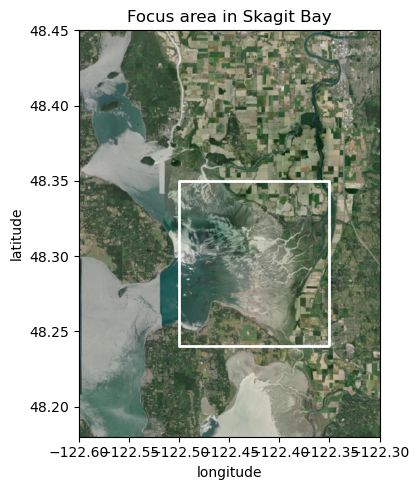

In [82]:
fig, ax = plt.subplots(figsize=(10,5))

bounds = skagit_gdf.total_bounds
ax.set_xlim(bounds[0], bounds[2])
ax.set_ylim(bounds[1], bounds[3])

ctx.add_basemap(ax, crs=metadata_gdf.crs, source=ctx.providers.Esri.WorldImagery, attribution=False)
ax.set_title("Focus area in Skagit Bay")
ax.set_xlabel('longitude')
ax.set_ylabel('latitude')
zoom_gdf.boundary.plot(ax=ax, color="white", linewidth=2)

fig.tight_layout()

**Step 6: let's explore our dateset with an RGB composite timeseries**

In [83]:
# First define the RBG data array

rgb_da = s2_ds[["B04", "B03", "B02"]].to_array(dim='band').compute()
rgb_da

<xarray.DataArray (band: 3, time: 11, latitude: 110, longitude: 150)> Size: 2MB
array([[[[  836.,   842.,   818., ...,   849.,  1124.,  1168.],
         [  837.,   819.,   844., ...,   695.,   698.,  1178.],
         [  806.,   830.,   802., ...,  1318.,  1155.,  1250.],
         ...,
         [  490.,   523.,   533., ...,  1627.,  1948.,  1612.],
         [  481.,   763.,   706., ...,  1226.,  1317.,  1949.],
         [  503.,   517.,   708., ...,  1439.,  1080.,   681.]],

        [[ 5157.,  5187.,  5200., ...,  4211.,  4184.,  4124.],
         [ 5150.,  5164.,  5185., ...,  4162.,  4095.,  4042.],
         [ 5148.,  5172.,  5173., ...,  4106.,  4067.,  4022.],
         ...,
         [ 4177.,  4193.,  4206., ...,  4874.,  4859.,  4821.],
         [ 4172.,  4189.,  4196., ...,  4814.,  4811.,  4785.],
         [ 4165.,  4189.,  4200., ...,  4807.,  4765.,  4727.]],

        [[ 1543.,  1367.,   921., ...,  2838.,  2664.,  1892.],
         [ 1753.,  1311.,  1330., ...,  3763.,  3354.,  3135.],
         [ 3000.,  3495.,  2692., ...,  4429.,  4063.,  3350.],
         ...,
...
         [ 1627.,  1801.,  3269., ...,  2369.,  2366.,  2457.],
         [ 1315.,  1396.,  2034., ...,  2209.,  2266.,  2186.],
         [ 1287.,  1419.,  1720., ...,  2140.,  1815.,  1873.]],

        [[12052., 11978., 11900., ...,  6232.,  5633.,  4322.],
         [12073., 11960., 11879., ...,  4952.,  4588.,  3963.],
         [12092., 12103., 11995., ...,  6143.,  6240.,  6083.],
         ...,
         [ 8348.,  8446.,  6073., ...,  5250.,  6004.,  6256.],
         [ 6579.,  7751.,  7072., ...,  5041.,  5440.,  5638.],
         [ 6899.,  6824.,  6248., ...,  5583.,  5667.,  5516.]],

        [[  663.,   682.,   592., ...,   417.,   398.,   506.],
         [  726.,   654.,   626., ...,   410.,   329.,   260.],
         [  680.,   655.,   690., ...,   876.,   252.,   252.],
         ...,
         [  190.,   206.,   283., ...,  1327.,  1423.,  1069.],
         [  202.,   552.,   488., ...,   956.,   966.,  2097.],
         [  205.,   222.,   421., ...,  1068.,   761.,   364.]]]],
      dtype=float32)
Coordinates:
  * latitude     (latitude) float64 880B 48.35 48.35 48.35 ... 48.24 48.24 48.24
  * longitude    (longitude) float64 1kB -122.5 -122.5 -122.5 ... -122.4 -122.4
    spatial_ref  int32 4B 4326
  * time         (time) datetime64[ns] 88B 2019-06-02T18:59:21.024000 ... 201...
  * band         (band) object 24B 'B04' 'B03' 'B02'

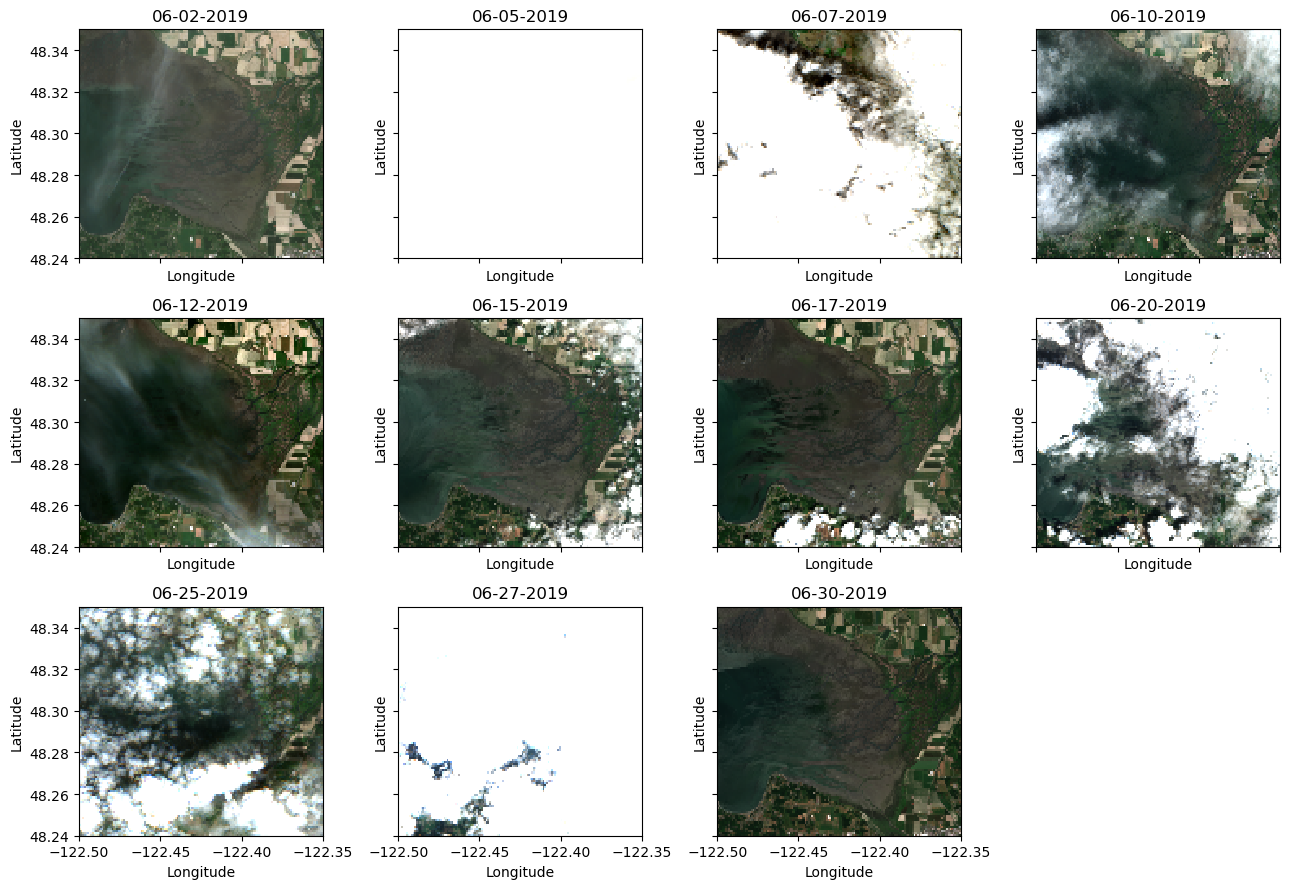

In [84]:
# Then plot all data available in June 2019
rgb_normalized = (rgb_da / 3000.0).clip(0, 1)

rgb = rgb_normalized.plot.imshow(col='time', col_wrap=4, robust=False)

for ax, t in zip(rgb.axes.flat, rgb_normalized.time.values):
    ax.set_title(pd.Timestamp(t).strftime("%m-%d-%Y"))
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")

plt.tight_layout()

After inspected our plots, it is clear that we are running into some cloud cover issues. We will clean that up when we plot our NDCI.

In [112]:
# filter asf

cloud_scl = [8, 9, 10]
cloud_fraction = s2_ds_water["SCL"].isin(cloud_scl).mean(dim=["latitude", "longitude"]).compute()
print(f"Cloud fractions:\n{cloud_fraction.values}")

cloud_threshold = 0.30

clean_times = cloud_fraction.time.where(cloud_fraction < cloud_threshold, drop=True)

print(f"Timesteps before: {len(s2_ds_water.time.values)}")
print(f"Timesteps after filtering: {len(clean_times.values)}")

Cloud fractions:
[0.55151515 0.5510303  0.50490909 0.10915152 0.11363636 0.08224242
 0.03563636 0.25866667 0.34927273 0.53842424 0.        ]
Timesteps before: 11
Timesteps after filtering: 6


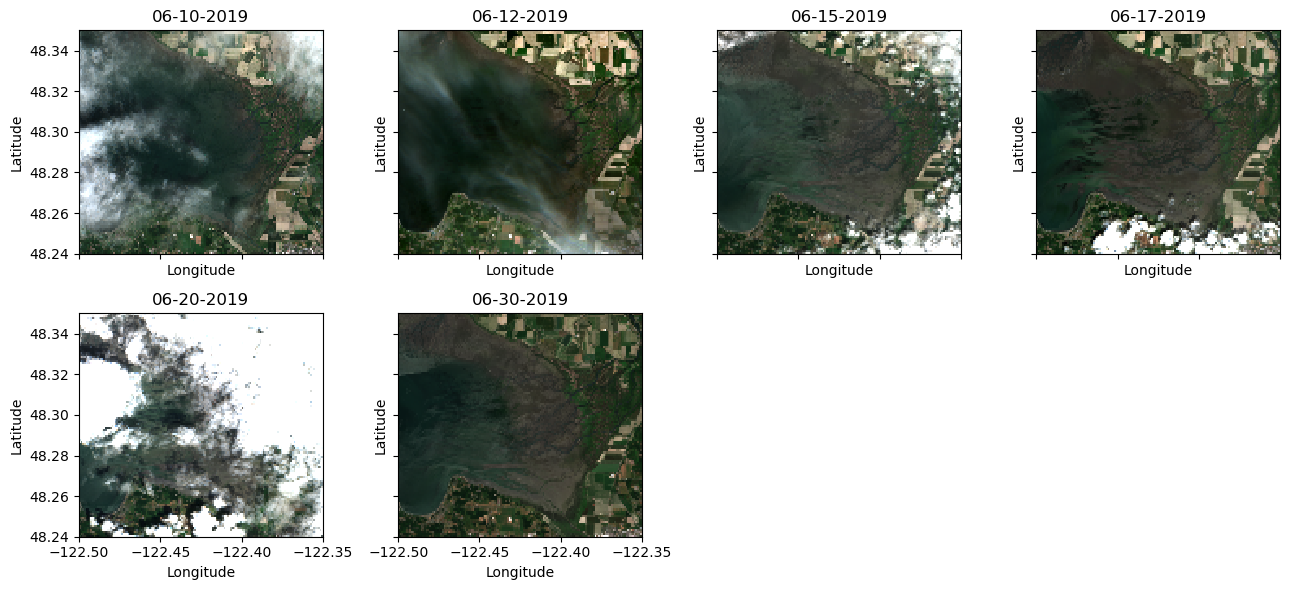

In [113]:
rgb_da = s2_ds[["B04", "B03", "B02"]].to_array(dim='band').sel(time=clean_times).compute()

rgb_normalized = (rgb_da / 3000.0).clip(0, 1)
rgb = rgb_normalized.plot.imshow(col='time', col_wrap=4, robust=False)
for ax, t in zip(rgb.axes.flat, rgb_normalized.time.values):
    ax.set_title(pd.Timestamp(t).strftime("%m-%d-%Y"))
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
plt.tight_layout()

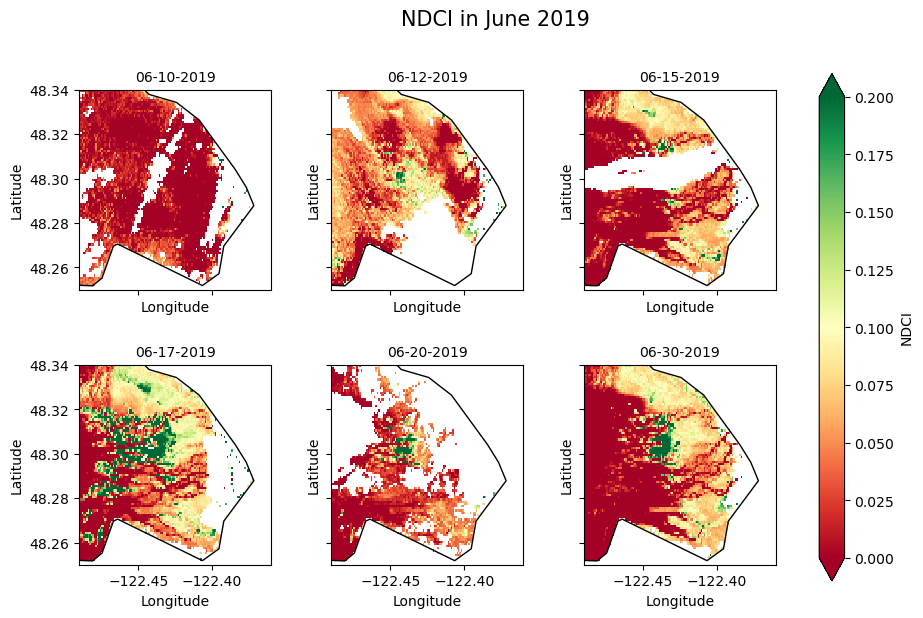

In [109]:
# now use s2_ds_water because we just want to track water not view the whole image

ndci_da = (s2_ds_water["B05"] - s2_ds_water["B04"]) / (s2_ds_water["B05"] + s2_ds_water["B04"])
water_only = s2_ds_water["SCL"] == 6
ndci_masked_da = ndci_da.where(water_only).sel(time=clean_times).compute()
ndci = ndci_masked_da.plot.imshow(col='time', col_wrap=3, robust=True, cmap='RdYlGn', vmin=0, vmax=0.20,  cbar_kwargs={"label": "NDCI"})

for ax, t in zip(ndci.axes.flat, ndci_masked_da.time.values):
    ax.set_title(pd.Timestamp(t).strftime("%m-%d-%Y"), fontsize=10)
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.set_xlim(zoom_bbox[0] + 0.01, zoom_bbox[2] - 0.01)
    ax.set_ylim(zoom_bbox[1] + 0.01, zoom_bbox[3] - 0.01)
    wa_gdf_clipped.boundary.plot(ax=ax, color='black', linewidth=1)

plt.suptitle("NDCI in June 2019", y=1.05, fontsize=15);

In [110]:
# Calculate the mean for each image

ndci_median = ndci_masked_da.median(dim=["latitude", "longitude"])
print(ndci_median.values)

[0.         0.05035971 0.01324105 0.05344827 0.01694882 0.00650422]


Questions:

could potentially load in skagit bay geometry and hard clip the vegetation out that way?
- i think the Nans are skewing my ncdi means

how to make it so it doesn't plot the bbox along with the coastline
- then could i clip everything outside of the coastline?

clip to a larger bounding box, make it have a fill of white and plot on top

create a new polygon just for the specific part of the bay with a 20% threshold or something (throw it out if not enough data)

In [ ]:
# mean gives numbers but median is giving 2 zeroes...


# do full timeseries from 2017 to now. only grab images with less than 30% cloud cover. can specify lower resolution


# can compare RBG and NDCI for a few sites to show how well it does it, along with indexing (maybe one with low versus 1 with high)

**Great, now this works for one month. Let's try this for all of 2019**
**MOVE THIS ALL TO NEW NOTEBOOK**

**IN ALLITEMS I ALSO FILTER CLOUD COVER**

In [ ]:
# notebooks folder for the notebooks

# can also add file with what to import